# Deep Learning Architectures: CNNs and RNNs

## 📚 Learning Objectives

By completing this notebook, you will:
- Describe CNN and RNN architectures and use cases
- Read and compare `model.summary()` outputs (training happens in notebooks 05-06)

## 🔗 Where this fits

**Builds on:** Unit 4, lesson 01 "Simple Perceptron" — one neuron becomes a layer, and layers become architectures with a shape.

**Used later in:** Course 08 (AIAT 122) — Units 2 and 3, which train the CNNs and RNNs only described here.

---


## 🎯 One contest result that redirected an industry

The ImageNet Large Scale Visual Recognition Challenge asks a model to name what
is in a photograph, over a thousand categories. In **2012** the entry from Alex
Krizhevsky, Ilya Sutskever and Geoffrey Hinton — a **convolutional neural
network**, now called AlexNet — finished with a top-5 error rate of **15.3%**.
The next best entry, built on the hand-engineered features that had dominated
computer vision for a decade, scored **26.2%**. That gap of nearly eleven points
ended one research programme and started another; within three years essentially
every serious vision system was a CNN.

The sequence side has an equally dated turning point. In **September 2016** Google
replaced the phrase-based statistical engine behind Google Translate with
**GNMT** — a stack of eight LSTM encoder layers and eight LSTM decoder layers with
attention. Google reported it reduced translation errors by **55-85%** on several
language pairs against the system it replaced, and put it into production first
for Chinese→English. The LSTM you are about to define below is the same cell type,
at a smaller size.

### What goes wrong without matching the architecture to the data

A `Dense` layer treats its inputs as an unordered bag of numbers. Feed it an image
and you have thrown away the fact that neighbouring pixels form strokes and edges;
feed it a sequence and you have thrown away the order. Both are recoverable only
by making the network relearn, from data, a structure you already knew. That is
what a convolution and a recurrence *are*: prior knowledge about the data's shape,
built into the wiring so the network does not have to spend capacity discovering it.


# Deep Learning Architectures: CNNs and RNNs

**Unit:** Unit 4: Neural Networks Fundamentals  

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand Convolutional Neural Networks (CNNs) structure
- Learn Recurrent Neural Networks (RNNs), LSTM, and GRU
- Compare CNNs and RNNs for different applications
- Define a CNN architecture and inspect its `model.summary()`
- Define RNN, LSTM, and GRU architectures and compare their parameter counts

**Note:** this notebook only *builds* the architectures — actual training on images
and sequences happens in notebooks 05 and 06.

---

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Map of the deep-learning architecture zoo: CNNs for spatial data, RNN/LSTM/GRU for
# sequences. Choosing the architecture that matches the data's structure is half the job.
import numpy as np
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, LSTM, GRU, SimpleRNN

print("=== Deep Learning Architectures ===")
print("\n1. CNN (Convolutional Neural Network):")
print("   - Best for: Images, spatial data")
print("   - Components: Convolution, Pooling, Fully Connected")
print("   - Applications: Image classification, object detection")

print("\n2. RNN (Recurrent Neural Network):")
print("   - Best for: Sequential data, time series")
print("   - Components: Recurrent layers, memory")
print("   - Applications: Text, speech, time series")

print("\n3. LSTM (Long Short-Term Memory):")
print("   - Advanced RNN with long-term memory")
print("   - Solves vanishing gradient problem")

print("\n4. GRU (Gated Recurrent Unit):")
print("   - Simpler than LSTM, similar performance")

=== Deep Learning Architectures ===

1. CNN (Convolutional Neural Network):
   - Best for: Images, spatial data
   - Components: Convolution, Pooling, Fully Connected
   - Applications: Image classification, object detection

2. RNN (Recurrent Neural Network):
   - Best for: Sequential data, time series
   - Components: Recurrent layers, memory
   - Applications: Text, speech, time series

3. LSTM (Long Short-Term Memory):
   - Advanced RNN with long-term memory
   - Solves vanishing gradient problem

4. GRU (Gated Recurrent Unit):
   - Simpler than LSTM, similar performance


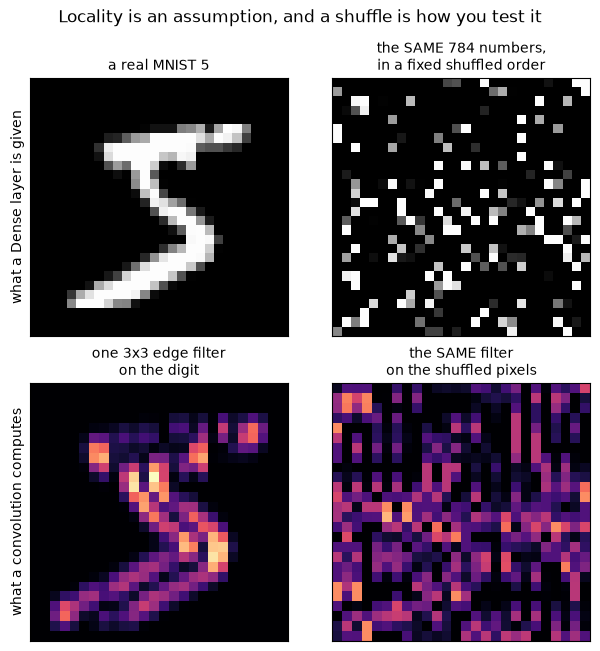

Do the two top images contain the identical 784 pixel values? True
  original  min 0.000  max 1.000  sum 107.941
  shuffled  min 0.000  max 1.000  sum 107.941

Mean |edge-filter response|:  digit 0.4549   shuffled 0.7819  (1.7x the digit's)
The filter still fires on the shuffled image - harder, in fact, because neighbouring
pixels are now unrelated. What it no longer does is fire on anything that means
something. A Dense layer never had that problem, because it never had that ability.


In [2]:
# WHAT/WHY: the paragraph above claims a Dense layer "throws away the fact that
# neighbouring pixels form strokes". That claim is the whole reason this notebook exists,
# and so far it is only a sentence. Here it is as a picture, on one real MNIST digit and
# with no training at all: shuffle the pixels with ONE fixed permutation, then look at
# what a dense layer sees versus what a convolution sees.
import matplotlib.pyplot as plt

(x_mnist, y_mnist), _ = keras.datasets.mnist.load_data()   # cached in ~/.keras
digit = x_mnist[0].astype(float) / 255.0                   # one real handwritten digit

rng = np.random.default_rng(0)          # randomness IS the operation being demonstrated
perm = rng.permutation(digit.size)      # ONE fixed pixel order, reused for every image
shuffled = digit.ravel()[perm].reshape(digit.shape)

# A hand-written vertical-edge detector - no learning, so nothing here depends on a model.
kernel = np.array([[1.0, 0.0, -1.0],
                   [2.0, 0.0, -2.0],
                   [1.0, 0.0, -1.0]])

def convolve(img, k):
    """Slide k over img (valid padding) - exactly what one Conv2D filter computes."""
    kh, kw = k.shape
    out = np.zeros((img.shape[0] - kh + 1, img.shape[1] - kw + 1))
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            out[i, j] = float((img[i:i + kh, j:j + kw] * k).sum())
    return out

edges_plain = np.abs(convolve(digit, kernel))
edges_shuf = np.abs(convolve(shuffled, kernel))
vmax = max(edges_plain.max(), edges_shuf.max())            # one scale for a fair comparison

fig, axes = plt.subplots(2, 2, figsize=(6.4, 6.6))
for ax, img, cmap, title in [
        (axes[0, 0], digit, "gray", f"a real MNIST {y_mnist[0]}"),
        (axes[0, 1], shuffled, "gray", "the SAME 784 numbers,\nin a fixed shuffled order"),
        (axes[1, 0], edges_plain, "magma", "one 3x3 edge filter\non the digit"),
        (axes[1, 1], edges_shuf, "magma", "the SAME filter\non the shuffled pixels")]:
    im = ax.imshow(img, cmap=cmap, vmin=0, vmax=(1.0 if cmap == "gray" else vmax))
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
axes[0, 0].set_ylabel("what a Dense layer is given", fontsize=10)
axes[1, 0].set_ylabel("what a convolution computes", fontsize=10)
fig.suptitle("Locality is an assumption, and a shuffle is how you test it", fontsize=12)
plt.tight_layout()
plt.show()

same_numbers = np.array_equal(np.sort(digit.ravel()), np.sort(shuffled.ravel()))
print(f"Do the two top images contain the identical 784 pixel values? {same_numbers}")
print(f"  original  min {digit.min():.3f}  max {digit.max():.3f}  sum {digit.sum():.3f}")
print(f"  shuffled  min {shuffled.min():.3f}  max {shuffled.max():.3f}  sum {shuffled.sum():.3f}")
print(f"\nMean |edge-filter response|:  digit {edges_plain.mean():.4f}   "
      f"shuffled {edges_shuf.mean():.4f}  "
      f"({edges_shuf.mean() / edges_plain.mean():.1f}x the digit's)")
print("The filter still fires on the shuffled image - harder, in fact, because neighbouring")
print("pixels are now unrelated. What it no longer does is fire on anything that means")
print("something. A Dense layer never had that problem, because it never had that ability.")


### 👀 Read the four panels

**Top row — the two inputs are the same input.** On the left, a handwritten **5** you can
read instantly. On the right, static. The printed check underneath says these two images
contain the **identical 784 pixel values** (same minimum, same maximum, same sum) — only
the order differs, and that order came from one permutation that would be applied to every
image in the dataset.

A `Dense` layer keeps one weight per input position and adds up the results. Apply the
same fixed shuffle to every image and you have simply relabelled which weight meets which
number: the sum, the model's capacity, and what it can learn are unchanged. **That is not
a measurement in this figure — it follows from the algebra** — but it is the precise sense
in which a dense layer "does not know" the picture on the left is a picture. It would
train just as happily on the right-hand one. Your eyes would not.

**Bottom row — what the shuffle destroyed.** The same hand-written 3×3 edge detector, no
learning involved, on both. On the left it traces the strokes of the 5: bright where ink
meets background, dark inside the strokes and dark in the empty corners. On the right it
is bright speckle spread over the whole frame with no shape in it at all.

And note the number, because it is the counter-intuitive part: the mean response is
**0.4549** on the digit and **0.7819** on the shuffled version — the filter fires **1.7×
harder** on the noise. It has not stopped working. Neighbouring pixels are simply
unrelated now, so every 3×3 window contains a big jump. The output is louder and
completely meaningless.

**That is what "inductive bias" means, concretely.** Convolution is not a better layer; it
is a layer that has *assumed* something about the input — that nearby pixels belong
together — and everything it buys is repaid only if that assumption is true. Take the
assumption away and the convolution is worse than useless while the dense layer is
unaffected. It is also why reaching for a CNN because your data "is a matrix" is a
mistake: shuffle the columns of a spreadsheet and nothing about the data has changed, so
there is no locality there to exploit. Notebook 05 measures what this assumption is worth
when it *does* hold.


## Example: CNN for Image Classification


In [3]:
# Build (not train) a small CNN and read its summary: watch the spatial size shrink
# through conv/pooling while the channel count grows — the CNN signature.
# Simple CNN architecture example
print("=== CNN Architecture Example ===")
print("\nCNN Structure:")
print("Input → Conv2D → MaxPooling → Conv2D → MaxPooling → Flatten → Dense → Output")

# Example CNN model (simplified for demonstration)
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(), Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

print("\nModel Summary:")
cnn_model.summary()
print("\n✅ CNN is designed for spatial patterns in images")

=== CNN Architecture Example ===

CNN Structure:
Input → Conv2D → MaxPooling → Conv2D → MaxPooling → Flatten → Dense → Output

Model Summary:


/Users/abdullah/venvs/ai-diploma-tf/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)


✅ CNN is designed for spatial patterns in images


## Example: RNN/LSTM for Sequential Data


In [4]:
# Same exercise for sequences: an LSTM reads 10 timesteps one by one and keeps a
# memory — its parameter count comes from the gates, visible in the summary.
# Simple RNN/LSTM architecture example
print("=== RNN/LSTM Architecture Example ===")
print("\nRNN Structure:")
print("Input sequence → RNN/LSTM layers → Dense → Output")

# Example LSTM model for sequence prediction
lstm_model = Sequential([
    LSTM(50, activation='relu', input_shape=(10, 1)),  # 10 timesteps, 1 feature
    Dense(1)
])

print("\nModel Summary:")
lstm_model.summary()
print("\n✅ LSTM/RNN is designed for temporal/sequential patterns")

=== RNN/LSTM Architecture Example ===

RNN Structure:
Input sequence → RNN/LSTM layers → Dense → Output

Model Summary:


/Users/abdullah/venvs/ai-diploma-tf/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)


✅ LSTM/RNN is designed for temporal/sequential patterns


## 📊 Read the two summaries side by side

Both models were only *built*, never trained — but their parameter counts already
tell you what each architecture assumes.

**In the CNN summary**, follow two numbers down the table: the spatial size shrinks
(28×28 → 26×26 → 13×13 → …) while the channel count grows (1 → 32 → 64). That is
the CNN signature — trade *where* something is for *what* it is. Notice also that
the first `Conv2D` has only **320** parameters: 32 filters × (3×3 kernel + 1 bias).
Those 320 numbers are reused at every one of the 676 positions in the image. A
`Dense` layer connecting 784 pixels to 32 units would need 25,120.

**In the LSTM summary**, the single `LSTM(50)` layer holds **10,400** parameters
for an input of 10 timesteps × 1 feature. Work out why: an LSTM has four internal
gates, each with weights over the input (1), the previous hidden state (50) and a
bias — 4 × (1 + 50 + 1) × 50 = 10,400. **The gates are where the parameters go**,
and that is the price of memory that survives many timesteps. Notebook 06 trains
all three cell types and shows what the price buys.


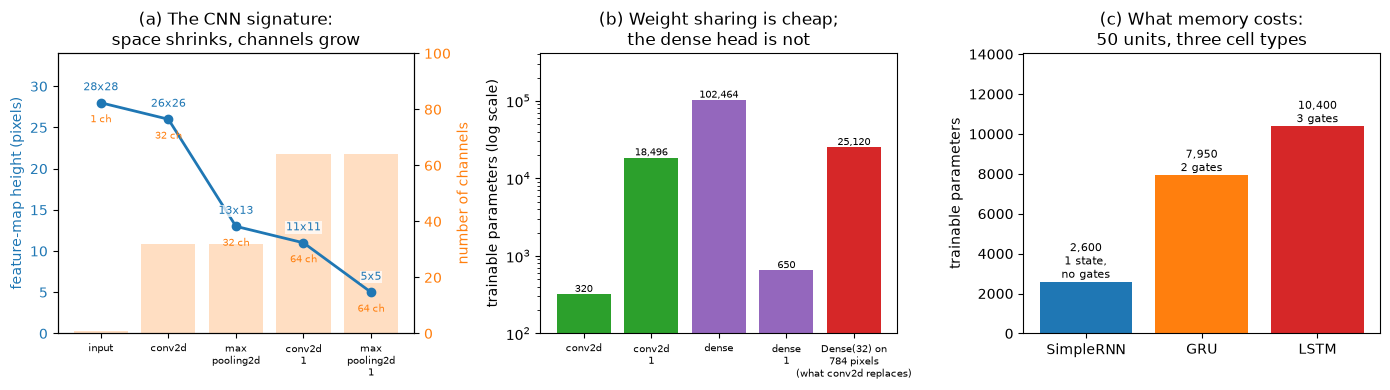

(a) 28x28x1 -> 5x5x64: 784 numbers become 1600, but arranged as 64 learned feature maps instead of raw pixels.
(b) first Conv2D: 320 parameters; a Dense(32) over the same 784 pixels: 25,120 (78x more).
    But note where this CNN's parameters actually live: 103,114 of 121,930 (85%) are in the DENSE head, not the convolutions.
(c) SimpleRNN 2,600, GRU 7,950, LSTM 10,400  ->  the LSTM costs 4.0x the SimpleRNN for the same 50 units.


In [5]:
# WHAT/WHY: the two summaries above are the whole lesson, but they are printed as
# tables and the shape story is easy to miss. This cell draws the SAME numbers, read
# straight out of the models we just built — nothing new is trained or invented.
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input   # not imported in the cell above

# --- (a) how the tensor changes shape as it moves through the CNN ---------------
names   = ["input"]
spatial = [28]        # height of the feature map
channels = [1]        # number of feature maps
for layer in cnn_model.layers:
    shape = layer.output.shape
    if len(shape) == 4:                    # only conv/pool layers keep 2D structure
        names.append(layer.name.replace("_", "\n"))
        spatial.append(int(shape[1]))
        channels.append(int(shape[3]))

# --- (b) what one convolution layer costs vs the dense layer it replaces ---------
conv_first = Sequential([Input(shape=(28, 28, 1)), Conv2D(32, (3, 3))])
dense_same = Sequential([Input(shape=(784,)), Dense(32)])   # 784 pixels -> 32 units
cnn_layer_params = [(l.name, l.count_params()) for l in cnn_model.layers
                    if l.count_params() > 0]

# --- (c) what the gates cost: same 50 units, three recurrent cells ---------------
cell_params = {}
for cell in (SimpleRNN, GRU, LSTM):
    cell_params[cell.__name__] = Sequential(
        [Input(shape=(10, 1)), cell(50)]).count_params()

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4.0))

x = range(len(names))
ax1.plot(x, spatial, "o-", color="tab:blue", lw=2, label="spatial size (height)")
ax1.set_ylabel("feature-map height (pixels)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.set_xticks(list(x)); ax1.set_xticklabels(names, fontsize=7)
ax1.set_ylim(0, 34)
ax1b = ax1.twinx()
ax1b.bar(x, channels, alpha=0.25, color="tab:orange", label="channels")
ax1b.set_ylabel("number of channels", color="tab:orange")
ax1b.tick_params(axis="y", labelcolor="tab:orange")
ax1b.set_ylim(0, 100)          # headroom so the bars do not swamp the line
ax1.set_zorder(ax1b.get_zorder() + 1); ax1.patch.set_visible(False)
ax1.set_title("(a) The CNN signature:\nspace shrinks, channels grow")
for xi, (sz, ch) in enumerate(zip(spatial, channels)):
    ax1.annotate(f"{sz}x{sz}", (xi, sz), textcoords="offset points", xytext=(0, 9),
                 ha="center", fontsize=8, color="tab:blue",
                 bbox=dict(fc="white", ec="none", alpha=0.75, pad=0.6))
    ax1.annotate(f"{ch} ch", (xi, sz), textcoords="offset points", xytext=(0, -14),
                 ha="center", fontsize=7, color="tab:orange")

labels = [n for n, _ in cnn_layer_params] + ["Dense(32) on\n784 pixels\n(what conv2d replaces)"]
values = [p for _, p in cnn_layer_params] + [dense_same.count_params()]
colors = ["tab:green" if n.startswith("conv") else "tab:purple"
          for n, _ in cnn_layer_params] + ["tab:red"]
bars = ax2.bar(range(len(values)), values, color=colors)
ax2.set_yscale("log")
ax2.set_xticks(range(len(values)))
ax2.set_xticklabels([l.replace("_", "\n") for l in labels], fontsize=7)
ax2.set_ylabel("trainable parameters (log scale)")
ax2.set_ylim(100, max(values) * 4)
ax2.set_title("(b) Weight sharing is cheap;\nthe dense head is not")
for b, v in zip(bars, values):
    ax2.annotate(f"{v:,}", (b.get_x() + b.get_width() / 2, v), fontsize=7,
                 ha="center", va="bottom")

names3 = list(cell_params)
vals3 = [cell_params[n] for n in names3]
bars3 = ax3.bar(names3, vals3, color=["tab:blue", "tab:orange", "tab:red"])
ax3.set_ylabel("trainable parameters")
ax3.set_title("(c) What memory costs:\n50 units, three cell types")
for b, v, note in zip(bars3, vals3, ["1 state,\nno gates", "2 gates", "3 gates"]):
    ax3.annotate(f"{v:,}\n{note}", (b.get_x() + b.get_width() / 2, v), fontsize=8,
                 ha="center", va="bottom")
ax3.set_ylim(0, max(vals3) * 1.35)

plt.tight_layout()
plt.show()

print(f"(a) 28x28x1 -> {spatial[-1]}x{spatial[-1]}x{channels[-1]}: "
      f"{28 * 28} numbers become {spatial[-1] * spatial[-1] * channels[-1]}, "
      f"but arranged as {channels[-1]} learned feature maps instead of raw pixels.")
print(f"(b) first Conv2D: {conv_first.count_params():,} parameters; a Dense(32) over the "
      f"same 784 pixels: {dense_same.count_params():,} "
      f"({dense_same.count_params() / conv_first.count_params():.0f}x more).")
dense_head = sum(p for n, p in cnn_layer_params if n.startswith("dense"))
print(f"    But note where this CNN's parameters actually live: "
      f"{dense_head:,} of {cnn_model.count_params():,} "
      f"({dense_head / cnn_model.count_params():.0%}) are in the DENSE head, not the convolutions.")
print("(c) " + ", ".join(f"{n} {v:,}" for n, v in cell_params.items()) +
      f"  ->  the LSTM costs {cell_params['LSTM'] / cell_params['SimpleRNN']:.1f}x the SimpleRNN for the same 50 units.")


### 👀 Read the three panels

**(a) The CNN signature.** The blue line falls (28 → 26 → 13 → 11 → 5) while the orange
bars rise (1 → 32 → 64). Every conv-pool block trades *where* a pattern is for *what* it
is. Nothing here is a design accident: `Conv2D(3x3)` shaves 2 pixels off each side
because a 3×3 window has no room at the border, and `MaxPooling2D(2,2)` halves the size
on purpose.

**(b) The cost of weight sharing — and where the money actually goes.** The first
`Conv2D` holds **320** parameters; a `Dense(32)` layer over the same 784 pixels holds
**25,120** — 78× more — for a layer that cannot recognise the same stroke in two places.
Now look at the tall purple bar: the `Dense(64)` head alone holds **102,464** of this
model's 121,930 parameters. **The convolutions are the cheap part.** That is a fact
students routinely get backwards, and it is why architectures after 2014 replaced the
big dense head with global pooling.

**(c) What gates cost.** Same 50 units, same 10-step input, three cell types: SimpleRNN
**2,600**, GRU **7,950**, LSTM **10,400** — 4× the SimpleRNN for the same width. The
parameters *are* the gates. Notebook 06 trains all three on a real signal and measures
whether that 4× buys anything on a short sequence. (It barely does — which is the point.)

## 💬 Discuss

1. The CNN's first layer reuses 320 parameters across every position in the image.
   That assumption — a useful pattern is useful *anywhere* in the input — is called
   translation invariance. **Name a kind of data where it is false**, and say what
   a CNN would get wrong there.
2. An LSTM processes timesteps one after another, so it cannot be parallelised
   across time; a transformer sees the whole sequence at once. Given the parameter
   count above, argue when you would still choose an LSTM in 2026 — think about
   sequence length, hardware, and the size of your dataset.
3. You have 5,000 labelled chest X-rays and a deadline. Build a CNN from scratch,
   or fine-tune a network pre-trained on everyday photographs? Commit to one, then
   name the result from notebook 05 that would make you switch.


## ⚠️ Where this breaks

- **This notebook builds architectures; it does not evaluate them.** A
  `model.summary()` proves the shapes are consistent and nothing else. Parameter
  counts are not quality, and the CNN below has never seen an image. Notebooks 05
  and 06 do the actual measuring, and one of them shows a *deeper* model failing
  to beat a shallower one.
- **A CNN assumes locality and translation invariance.** Both hold for photographs
  and hold badly for tabular data, where column order is arbitrary — shuffle the
  columns of a spreadsheet and nothing changes about the data, but a convolution
  over them becomes meaningless. Reaching for a CNN because the input "is a
  matrix" is a common and expensive mistake.
- **Pooling throws away position on purpose.** Great for "is there a cat";
  actively harmful when the answer depends on *where* something is, which is why
  detection and segmentation networks are built differently.
- **A SimpleRNN cannot hold long-range information.** Its single state vector is
  overwritten at every step, so gradients over long sequences vanish. LSTM and GRU
  exist as fixes, and they are partial ones — Unit 4, notebook 06 measures a case
  where they barely beat the SimpleRNN because the useful history is short.
- **This framing predates the current architecture landscape.** "CNNs for images,
  RNNs for sequences" was the right map in 2016. Since then transformers have
  taken most sequence work, vision transformers compete with CNNs on large
  datasets, and transformer backbones now drive *image generation* too (Peebles &
  Xie, 2022, *Scalable Diffusion Models with Transformers*). Learn the two
  inductive biases here — locality and recurrence — as ideas, then expect the
  default architecture to have moved by the time you deploy.
- **Bigger is not the answer to a wrong bias.** If the architecture encodes the
  wrong assumption about your data, adding layers spends compute making the wrong
  assumption more confidently.


## 🔭 State of the field (2026)

Both halves of this notebook have moved on. On the vision side, "pretrained backbone" in 2026 usually
means an open vision-language model rather than an ImageNet-trained CNN: one model reads images,
documents and video and answers in text, and it is what most teams reach for before training a
convolutional network of their own (Bai et al., 2025). Convolution also stopped being the generative
default — replacing the U-Net with a transformer gave diffusion models a clean scaling story, and that
DiT design sits underneath the image and video generators of the last three years (Peebles & Xie,
2022). On the sequence side the recurrent idea did not die: xLSTM revisited the LSTM's gates with
modern training practice and scaled them to language-model sizes, which is the honest 2024 answer to
"why would anyone still use a recurrent cell?" (Beck et al., 2024).

Keep building these two by hand anyway. Convolution is where you learn weight sharing and locality;
the LSTM's gates are where you learn what memory costs — and the parameter counts you just compared
(320 against 10,400) are the cheapest demonstration of both in the whole diploma. Course 08 trains
these architectures; the official plan examines them.

*Orientation only — the assessed content of this lesson is everything above this box.*

## 📚 References

1. LeCun, Y., Bottou, L., Bengio, Y., & Haffner, P. (1998). *Gradient-Based Learning Applied to Document Recognition*. Proceedings of the IEEE, 86(11), 2278–2324.
2. Hochreiter, S., & Schmidhuber, J. (1997). *Long Short-Term Memory*. Neural Computation, 9(8), 1735–1780.
3. Krizhevsky, A., Sutskever, I., & Hinton, G. E. (2012). *ImageNet Classification with Deep Convolutional Neural Networks*. NeurIPS.
4. Dosovitskiy, A., Beyer, L., Kolesnikov, A., et al. (2021). *An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale* (ViT). ICLR. <https://arxiv.org/abs/2010.11929>
5. Bai, S., Cai, Y., Chen, R., et al. (2025). *Qwen3-VL Technical Report*. arXiv. <https://arxiv.org/abs/2511.21631>
6. Beck, M., Pöppel, K., Spanring, M., et al. (2024). *xLSTM: Extended Long Short-Term Memory*. arXiv. <https://arxiv.org/abs/2405.04517>
7. Peebles, W., & Xie, S. (2022). *Scalable Diffusion Models with Transformers* (DiT). arXiv. <https://arxiv.org/abs/2212.09748>